# Part IV — Geometry and Visualization
## Chapters 91–120

> **Prerequisites:** Parts I–III. You need: coordinate systems (ch098), functions (ch051),
> trigonometry (ch101–104), Python + numpy + matplotlib.
>
> **You will build:** a 2D geometry visualizer (ch119), a physics motion simulator (ch120),
> and a deep toolkit for spatial reasoning in 2D and 3D.

---

## What This Part Covers

Part III gave you functions — rules that map inputs to outputs.
Part IV gives you **space** — the geometric stage where functions act.

You will learn to work with:
- Points, lines, distances, and angles in 2D and 3D
- Trigonometry as the language of angles and periodic motion
- Geometric transformations: rotation, scaling, reflection, translation
- Curves beyond functions: circles, spirals, Bézier curves, splines
- The mathematical foundations of computer graphics

The central theme: **geometry is linear algebra in disguise.**
Every transformation in this Part is a matrix operation — a preview of Part VI.

---

## The Mental Shift

In Parts I–III you thought about functions:
> "What is the output when the input is x?"

In Part IV you think about **geometry**:
> "Where is this point in space? How does it move? What shape does it trace?"

Numbers become coordinates. Functions become transformations. Outputs become positions.

A key realization: **all geometric operations are linear maps.**
Rotating a point 30°, scaling it by 2, reflecting it across a line — each is a matrix multiplication.
You will see this machinery in Part VI (Linear Algebra), but you will build the intuition here.

The other shift: from exact functions to **parametric descriptions**.
Instead of y = f(x), you write:
- x(t) = cos(t)
- y(t) = sin(t)

This traces a circle — something that is not a function (it fails the vertical line test),
but is perfectly describable parametrically. Parametric thinking opens up all of curve geometry.

---

## Part Map: What Connects to What

```
ch091 Geometry in Programming
ch092 Points and Coordinate Systems
ch093 Cartesian Coordinates
ch094 Distance Between Points ──────────────────────┐
ch095 Midpoints and Interpolation                    │
ch096 Slopes and Lines                               │
ch097 Line Equations                                 │  Euclidean Geometry
ch098 Intersections                                  │  (the plane)
ch099 Circles and Geometry ─────────────────────────┘
ch100 Angle Measurement
ch101 Trigonometry Intuition ───────────────────────┐
ch102 Sine and Cosine                                │
ch103 Unit Circle                                    │  Trigonometry
ch104 Wave Functions                                 │  (angles and cycles)
ch105 Periodic Motion ──────────────────────────────┘
ch106 Polar Coordinates ────────────────────────────┐
ch107 Parametric Curves                              │  Beyond Cartesian
ch108 Geometric Transformations                      │
ch109 Rotation ─────────────────────────────────────┘
ch110 Scaling
ch111 Reflection
ch112 Translation ──────────────────────────────────┐
ch113 Geometric Composition                          │  Transformations
ch114 Affine Transformations                         │  (the algebra of geometry)
ch115 Computer Graphics Basics ─────────────────────┘
ch116 Bézier Curves ────────────────────────────────┐
ch117 Interpolation and Splines                      │  Curves
ch118 Geometry in Game Development ─────────────────┘
ch119 Project: 2D Geometry Visualizer
ch120 Project: Physics Motion Simulator
```

The geometric toolkit culminates in ch114 (Affine Transformations) — the single framework
that unifies rotation, scaling, reflection, and translation into one matrix formula.

---

## Prerequisites from Prior Parts

From **Part II** (Numbers):
- Floating-point arithmetic (ch018) — coordinates are floats; precision matters
- Modular arithmetic (ch011) — angle wrapping uses modulo

From **Part III** (Functions):
- Function composition (ch054) — geometric transformations compose the same way
- Parametric thinking (ch067–068) — x(t), y(t) is a function applied to a parameter
- Function transformations (ch066) — spatial transformations are the same idea in 2D

---

## Motivating Problem: Can You Solve This Now?

Here is a problem you cannot yet solve efficiently. By ch114, it will be trivial.

**Problem:** You have a polygon with 5 vertices. Apply the following sequence:
1. Rotate 45° around the origin
2. Scale by 2 along the x-axis
3. Translate by (3, -1)
4. Reflect across y = x

Plot the original and transformed polygon.

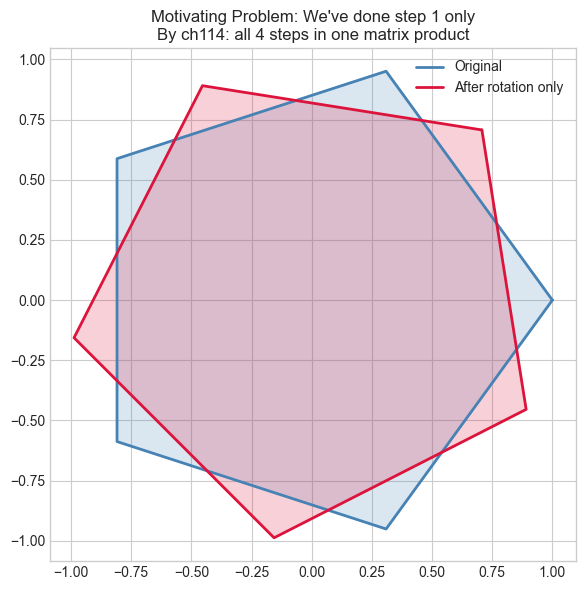

By end of Part IV:
  transformation = T_reflect @ T_translate @ T_scale @ T_rotate
  result = polygon @ transformation.T
  — one line of code for the full sequence


In [1]:
# Motivating problem — this will fail or be clumsy without Part IV tools
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Pentagon vertices
theta = np.linspace(0, 2*np.pi, 6)[:-1]
polygon = np.column_stack([np.cos(theta), np.sin(theta)])

# YOU CANNOT YET DO THIS CLEANLY.
# Attempt: manually apply each transformation
def rotate(pts, angle_deg):
    a = np.radians(angle_deg)
    R = np.array([[np.cos(a), -np.sin(a)],
                  [np.sin(a),  np.cos(a)]])
    return pts @ R.T

# After Part IV, you will apply all 4 transforms in ONE matrix multiplication
# using homogeneous coordinates (ch114)
rotated = rotate(polygon, 45)

fig, ax = plt.subplots(figsize=(8, 6))
poly = np.vstack([polygon, polygon[0]])
rot  = np.vstack([rotated, rotated[0]])
ax.fill(poly[:,0], poly[:,1], alpha=0.2, color='steelblue')
ax.plot(poly[:,0], poly[:,1], 'steelblue', linewidth=2, label='Original')
ax.fill(rot[:,0],  rot[:,1],  alpha=0.2, color='crimson')
ax.plot(rot[:,0],  rot[:,1],  'crimson',  linewidth=2, label='After rotation only')
ax.set_aspect('equal')
ax.set_title("Motivating Problem: We've done step 1 only\nBy ch114: all 4 steps in one matrix product")
ax.legend(); plt.tight_layout(); plt.show()

print("By end of Part IV:")
print("  transformation = T_reflect @ T_translate @ T_scale @ T_rotate")
print("  result = polygon @ transformation.T")
print("  — one line of code for the full sequence")

---

## Part IV in Three Sentences

Geometry is the study of **where things are** and **how they move**.
Every movement — rotate, scale, flip, slide — is a matrix multiplication (you'll prove this in ch114).
Trigonometry is the bridge between **angles** and **coordinates** that makes all spatial computation possible.

**Start here:** ch091 — Geometry in Programming.